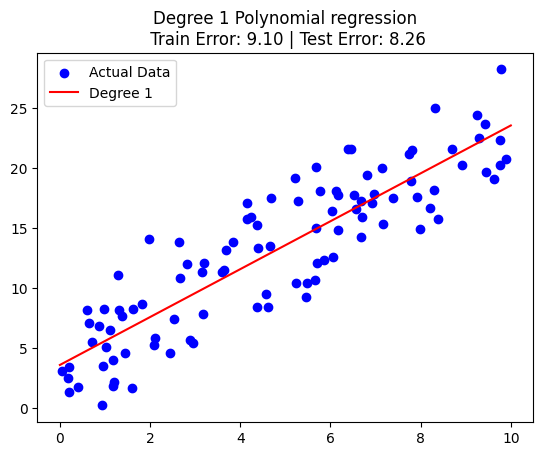

In [1]:
'''Alex wants to predict the height of magical plants based on sunlight exposure, but as he increases the degree of his polynomial regression model, he starts overfitting.

# Alex collects data on plant height (y) and sunlight (X)

np.random.seed(0)

X = np.random.rand(100, 1) * 10

y = 3 + 2 * X + np.random.randn(100, 1) * 3

TASK:

Collect data on plant height and sunlight.
Split the data into training and testing sets.
Train a polynomial regression model with different degrees.
Plot and compare training and test errors.
Check for overfitting when high-degree polynomial fits training data too well but fails on test data.


HINT:

Data Generation:

The program simulates data for plant height (y) based on the amount of sunlight (X) using a linear relationship with some added random noise. This is similar to real-world scenarios where data is not perfect.
X is generated as random values between 0 and 10, and y follows the equation y = 3 + 2*X + noise.
Splitting the Data:

The dataset is split into training (80%) and testing (20%) using train_test_split(). This allows us to train the model on one portion of the data and evaluate its performance on another.
Polynomial Transformation:

For each polynomial degree (1, 4, and 15), the program transforms the input features (X_train, X_test) into polynomial features using PolynomialFeatures. This adds new features like X^2, X^3, etc., depending on the degree.
This process enables the model to capture more complex relationships between X and y.
Training the Model:

A Linear Regression model is trained using the transformed polynomial features. Even though the model is linear, the addition of polynomial features allows it to fit non-linear data.
Predictions:

The model makes predictions for both the training data (y_train_pred) and the test data (y_test_pred).
The performance of the model is measured using the Mean Squared Error (MSE) for both the training and testing sets.
Error Calculation:

The program calculates the training error and testing error to assess how well the model fits the training data and how well it generalizes to new data (test set).
A large gap between training and test errors can indicate overfitting (when the model is too complex).
Plotting:

The program visualizes the results by plotting the actual data points (scatter plot) and the model’s predictions (red line) for different polynomial degrees.
The plot shows how increasing the polynomial degree makes the model fit the data better (low training error), but at higher degrees, it may overfit, leading to poor generalization (high test error).

'''
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import random

np.random.seed(0)

X = np.random.rand(100, 1) * 10

y = 3 + 2 * X + np.random.randn(100, 1) * 3

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

for degree in [1]:
    poly = PolynomialFeatures(degree)
    x_train_poly = poly.fit_transform(X_train)
    x_test_poly = poly.fit_transform(X_test)
    model = LinearRegression()
    model.fit(x_train_poly, y_train)

    y_train_pred = model.predict(x_train_poly)
    y_test_predict = model.predict(x_test_poly)

train_error = mean_squared_error(y_train, y_train_pred)
test_error = mean_squared_error(y_test, y_test_predict)

x_range = np.linspace(0,10,100).reshape(-1,1)
x_range_poly = poly.transform(x_range)
y_range_pred = model.predict(x_range_poly)

plt.scatter(X,y,color = "blue", label = "Actual Data")

plt.plot(x_range, y_range_pred, color = "red", label = f"Degree {degree}")
plt.title(f"Degree {degree} Polynomial regression\n Train Error: {train_error:.2f} | Test Error: {test_error:.2f}")
plt.legend()
plt.show()


